# Admisión invariante a la latencia mediante asignación hash en ventanas dinámicas

**Resumen.** En ventas y registros masivos (entradas, lanzamientos, cupos) la
demanda instantánea supera por órdenes de magnitud a la capacidad. El mecanismo
habitual, atender *por orden de llegada* (FIFO), parece neutral pero no lo es: la
posición depende de la latencia de cada cliente, y ahí una persona no puede
competir con un script. El resultado es que el frente de la cola se llena de
tráfico automatizado antes de que un humano termine de cargar la página.

Este trabajo caracteriza el problema y propone asignar la posición mediante un
**hash con secreto de la identidad, proyectado sobre una ventana dimensionada por
la población en espera**. Como resultado, este reparto es independiente de la
velocidad e impredecible, acota la carga al backend, y deja como única palanca el
*volumen de identidades*.

## 1. El problema

Un evento de alta demanda concentra, en los primeros segundos tras la apertura,
una avalancha de solicitudes muy superior a los cupos disponibles. Hay que
ordenarlas de alguna forma, y la elección por defecto, casi siempre implícita,
es el **orden de llegada**: el primero que toca la puerta, pasa primero.

El problema es que "llegar primero" no mide intención ni legitimidad, mide
**latencia**. Y en latencia el campo de juego está completamente desnivelado:

- Un script envía su solicitud en el milisegundo cero, en paralelo, desde
  infraestructura cercana al servidor, reintentando sin fatiga.
- Una persona tiene que ver que abrió, mover el mouse, hacer clic; su navegador
  negocia TLS, descarga el HTML, ejecuta el JavaScript. Son cientos de
  milisegundos a varios segundos.

Cuando el criterio de orden es la velocidad, **el humano ya perdió antes de
empezar**: para cuando su solicitud llega, miles de solicitudes automatizadas
ocupan el frente. No es un caso raro ni un ataque sofisticado; es el resultado
esperado de usar FIFO frente a adversarios con ventaja de latencia. La cola es
formalmente "justa" (atiende en orden) y materialmente injusta (ordena por quien
automatiza mejor).

Peor aún: detectar "bot vs. humano" a ciegas, en el borde y en tiempo real, es
poco fiable. Así que el objetivo no puede ser *clasificar* para excluir, sino
**diseñar el reparto para que la velocidad deje de comprar posición**, aunque no
sepamos quién es quién.

En lo que sigue: notación **azul = tráfico automatizado** (llega primero y en
ráfaga), **rojo = personas** (llegan después y más lento).

## 2. Modelo propuesto

La idea es sacar la posición de una fuente que el cliente no controla y que no
premia la velocidad. A cada participante se le asigna una posición
determinística a partir de un hash con secreto de su identidad (*device*),
proyectada sobre la población viva, y se admite a un ritmo fijo:

$$\text{frac} = \frac{\mathrm{HMAC}(secret,\; event\,\|\,device)}{2^{48}} \sim \mathrm{Uniforme}[0,1)$$

$$\text{posición} = \big\lfloor \text{frac}\cdot N\cdot(1+h) \big\rfloor \;+\; \max(0,\ \text{penalty}-\text{aging})$$

$$\text{cursor}(t) = \text{rate}\cdot \max(0,\ t-t_0), \qquad \text{admitido} \iff t\ge t_0 \ \wedge\ \text{posición}\le\text{cursor}(t)$$

donde $N$ es la cantidad de participantes activos y $h$ es el *headroom*
(sobredimensiona la ventana: $N$ personas sobre $N(1+h)$ slots $\Rightarrow$ quedan
huecos, para que el hash no cope todos los puestos al abrir). El punto clave: la
**hora de llegada no aparece en la fórmula**. La posición depende solo del hash,
así que llegar un milisegundo antes no mejora el puesto.

### 2.1 Grupos adimensionales
El comportamiento depende de tres cantidades: $\rho = K/N$ (fracción admitida, que
crece con el tiempo a medida que avanza el cursor), $p = P/N$ (penalización por
volumen, relativa a $N$) y $k$ (identidades por atacante).

### 2.2 Equidad (con frac ~ Uniforme)
$$P(\text{admite}\mid \text{humano}) = \min(1,\rho)$$
$$P(\text{admite}\mid \text{dueño-bot con }k\text{ identidades}) = 1-(1-q)^k,\quad q=\mathrm{clamp}(\rho-(k-1)p,0,1)$$
$$\text{Advantage Ratio} = \frac{1-(1-q)^k}{\min(1,\rho)}$$

La velocidad no aparece en ninguna de estas expresiones. La única palanca que le
queda al adversario es *cuántas identidades* controla, y eso cuesta dinero
(~$1/\rho$ IPs por cada slot de primera fila).

## 3. Simulación

Construimos una población de 1000 solicitudes con una pequeña minoría humana y
comparamos las dos reglas de admisión, orden de llegada (FIFO) y hash, sobre
*exactamente la misma* población.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

rng = np.random.default_rng(7)

N = 1000                      # total de solicitudes
human_frac = 0.08             # 8% son personas reales
is_human = rng.random(N) < human_frac
n_humans = int(is_human.sum())

# Hora de llegada: el tráfico automatizado dispara de inmediato (ráfaga); las
# personas llegan repartidas y más lento. Los bots son MÁS RÁPIDOS, no menos.
arrival = np.where(is_human,
                   rng.uniform(0.0, 1.00, N),   # personas: llegada natural y lenta
                   rng.uniform(0.0, 0.50, N))   # bots: al inicio

# FIFO: la posición es el orden de llegada (el más rápido primero).
fifo_pos = np.argsort(np.argsort(arrival))

# HASH: posición = hash de la identidad, repartida en una ventana con headroom.
# Slots únicos en [0, N*(1+h)) => quedan N*h huecos (independiente de la llegada).
headroom = 0.3
span = int(N * (1 + headroom))
hash_pos = rng.permutation(span)[:N]

K = 100                       # la “ventana escasa”: solo el top-K se lleva cupos
print(f'{N} solicitudes: {N-n_humans} bots (azul), {n_humans} personas (rojo)')
print(f'headroom={headroom} -> {span} slots, {span-N} huecos ({100*(span-N)/span:.0f}% libre)')

1000 solicitudes: 914 bots (azul), 86 personas (rojo)
headroom=0.3 -> 1300 slots, 300 huecos (23% libre)


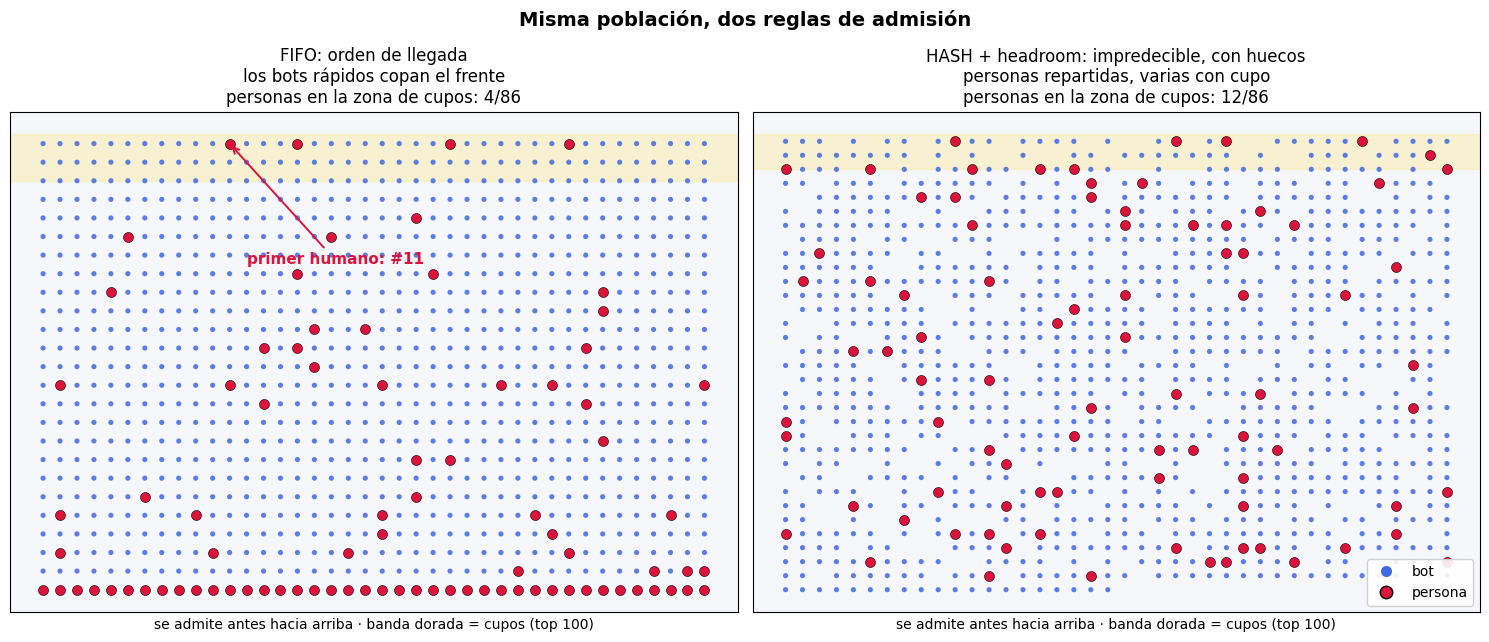

In [2]:
# Visualizamos la cola como una grilla (estilo “sectores de disco”). Posición baja
# = admitido antes = arriba. Celda vacía = hueco. Banda dorada = los K primeros,
# que son los que se llevan cupos.
COLS = 40
ROWS_K = K / COLS
def grid_xy(pos):
    pos = np.asarray(pos)
    return pos % COLS, pos // COLS

def panel(ax, pos, title):
    ax.axhspan(-0.5, ROWS_K - 0.5, color='gold', alpha=0.16, zorder=0)
    bx, by = grid_xy(pos[~is_human])
    ax.scatter(bx, by, c='royalblue', s=14, alpha=0.85, edgecolors='none', zorder=2)
    hx, hy = grid_xy(pos[is_human])
    ax.scatter(hx, hy, c='crimson', s=52, edgecolors='black', linewidths=0.4, zorder=3)
    hin = int(((pos < np.sort(pos)[K]) & is_human).sum())
    ax.set_title(title + f'\npersonas en la zona de cupos: {hin}/{n_humans}', fontsize=12)
    ax.invert_yaxis(); ax.set_xticks([]); ax.set_yticks([]); ax.set_facecolor('#f6f7fb')
    ax.set_xlabel('se admite antes hacia arriba · banda dorada = cupos (top 100)')

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
panel(axes[0], fifo_pos, 'FIFO: orden de llegada\nlos bots rápidos copan el frente')
hidx = np.where(is_human)[0]
fhi = hidx[np.argmin(fifo_pos[hidx])]
fx, fy = grid_xy(fifo_pos[fhi])
axes[0].annotate(f'primer humano: #{int(fifo_pos[fhi])}',
                 xy=(fx, fy), xytext=(COLS * 0.30, ROWS_K + 4.0),
                 color='crimson', fontsize=11, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='crimson', lw=1.4))
panel(axes[1], hash_pos, 'HASH + headroom: impredecible, con huecos\npersonas repartidas, varias con cupo')

legend = [Line2D([0],[0], marker='o', color='w', markerfacecolor='royalblue', label='bot', markersize=9),
          Line2D([0],[0], marker='o', color='w', markerfacecolor='crimson', markeredgecolor='black', label='persona', markersize=9)]
axes[1].legend(handles=legend, loc='lower right', framealpha=0.9)
fig.suptitle('Misma población, dos reglas de admisión', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

**Lectura de la figura.** La banda dorada (arriba) son los puestos que se llevan
cupos. A la izquierda (FIFO) esa banda es un **muro azul**: el tráfico
automatizado disparó primero y copó el frente; la persona más rápida recién
aparece alrededor del puesto ~30-50 (quedó detrás de decenas de bots) y el
resto, mucho más atrás. A la derecha (hash) la grilla está **dispersa y con
huecos** (el headroom), y los rojos quedan **repartidos, varios dentro de la zona
de cupos**, porque el puesto sale del hash y no de quién llegó antes.

In [3]:
# Lo mismo en números.
def front_humans(pos):
    return int(((pos < np.sort(pos)[K]) & is_human).sum())

fair = K * n_humans / N        # cuota proporcional de personas en el top-K
print(f'Posición MEDIANA de las personas:  FIFO={int(np.median(fifo_pos[is_human]))}'
      f'   HASH={int(np.median(hash_pos[is_human]))}   (de {N})')
print(f'Personas en la zona de cupos (top {K}):  FIFO={front_humans(fifo_pos)}'
      f'   HASH={front_humans(hash_pos)}   (cuota justa ≈ {fair:.0f})')
print('\nFIFO empuja a las personas hacia atrás; el hash las deja en su cuota\n'
      'proporcional, sin importar la velocidad de los bots.')

Posición MEDIANA de las personas:  FIFO=952   HASH=690   (de 1000)
Personas en la zona de cupos (top 100):  FIFO=4   HASH=12   (cuota justa ≈ 9)

FIFO empuja a las personas hacia atrás; el hash las deja en su cuota
proporcional, sin importar la velocidad de los bots.


## 4. Lo que queda: el volumen (y su costo)

El hash iguala a todos *por identidad*. Lo \u00fanico que sigue dando ventaja es tener
**muchas identidades** (best-of-$k$: con $k$ intentos, basta que uno caiga bien),
y eso se paga en IPs reales. La figura siguiente muestra el *Advantage Ratio* de
un due\u00f1o-bot con $k$ identidades frente a la penalizaci\u00f3n fraccional $p$: con
$p\approx \rho/k$ la ventaja se neutraliza (cae a 1).

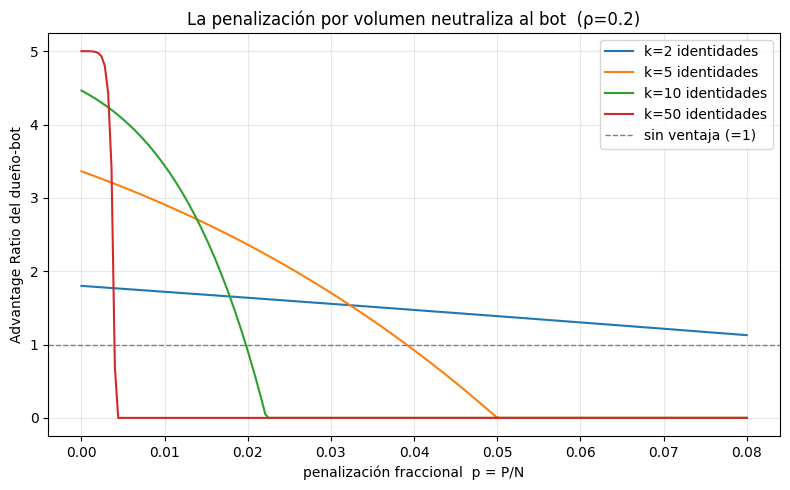

In [4]:
def advantage_ratio(rho, p, k):
    q = np.clip(rho - (k - 1) * p, 0, 1)
    return (1 - (1 - q) ** k) / min(1.0, rho)

rho = 0.2
ps = np.linspace(0, 0.08, 200)
plt.figure(figsize=(8, 5))
for k in (2, 5, 10, 50):
    plt.plot(ps, [advantage_ratio(rho, p, k) for p in ps], label=f'k={k} identidades')
plt.axhline(1.0, color='gray', ls='--', lw=1, label='sin ventaja (=1)')
plt.xlabel('penalización fraccional  p = P/N')
plt.ylabel('Advantage Ratio del dueño-bot')
plt.title(f'La penalización por volumen neutraliza al bot  (ρ={rho})')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 5. Conclusiones

- **La velocidad deja de comprar posici\u00f3n.** El puesto sale del hash, no de la
  hora de llegada (secci\u00f3n 3): un humano puede quedar en primera fila a pesar de
  cientos de bots m\u00e1s r\u00e1pidos.
- **Impredecibilidad.** Como $\text{frac}=\mathrm{HMAC}(secret,\cdot)$, sin el
  secreto no se puede predecir ni "minar" offline una identidad con buena
  posici\u00f3n.
- **Carga al backend acotada.** Se admite a `rate`; nadie provoca una estampida.
- **El volumen se vuelve costo.** Lo \u00fanico que compra ventaja es controlar muchas
  identidades, y eso cuesta ~$1/\rho$ IPs por slot de primera fila (secci\u00f3n 4).

FairQueue no intenta resolver el problema irresoluble de clasificar bot/humano a
ciegas. En su lugar hace que el reparto sea **justo, impredecible y lento por
construcci\u00f3n**, y convierte la ventaja de la automatizaci\u00f3n en **costo de
capital** en vez de en mejores puestos.